In [67]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import pandas as pd

In [68]:
import numpy as np

# Rotation matrix: equatorial (ICRS/J2000) → galactic
R_EQ2GAL = np.array([
    [-0.0548755604, -0.8734370902, -0.4838350155],
    [ 0.4941094279, -0.4448296300,  0.7469822445],
    [-0.8676661490, -0.1980763734,  0.4559837762]
])

def radec_to_galactic(ra, dec, degrees=True):
    """
    Convert equatorial (RA, Dec) → galactic (l, b)

    Parameters
    ----------
    ra, dec : array-like or float
        Right ascension and declination
    degrees : bool
        If True, input/output in degrees; otherwise radians

    Returns
    -------
    l, b : ndarray
        Galactic longitude and latitude
    """

    ra = np.asarray(ra)
    dec = np.asarray(dec)

    # Convert to radians if needed
    if degrees:
        ra = np.deg2rad(ra)
        dec = np.deg2rad(dec)

    # Spherical → Cartesian
    cos_dec = np.cos(dec)
    x = cos_dec * np.cos(ra)
    y = cos_dec * np.sin(ra)
    z = np.sin(dec)

    vec_eq = np.stack([x, y, z], axis=0)

    # Rotate
    vec_gal = R_EQ2GAL @ vec_eq

    xg, yg, zg = vec_gal

    # Cartesian → spherical
    b = np.arcsin(zg)
    l = np.arctan2(yg, xg)

    # Normalize l to [0, 2π)
    l = np.mod(l, 2*np.pi)

    if degrees:
        l = np.rad2deg(l)
        b = np.rad2deg(b)

    return l, b

In [69]:
# Galactic center ≈ (RA, Dec) = (266.4051°, -28.936175°)
l, b = radec_to_galactic(266.4051, -28.936175)

# Expect: l ≈ 0°, b ≈ 0°
print(l, b)

# V4641 Sgr
print(radec_to_galactic(274.84013930071, -25.40717856717))

4.7083266397785683e-05 -7.912588206549092e-05
(6.773952301677754, -4.78906886331538)


In [94]:
glade = np.load("GLADE_below01.npz")
galaxies = pd.DataFrame(np.array([glade['ra'], glade['dec'], glade['z']]).T, columns=['ra', 'dec', 'z'])
glade.close()

In [95]:
galaxies.head()

,ra,dec,z
0,188.860123,14.496320,0.003573
1,267.360474,70.144341,0.002803
2,187.016220,9.803620,0.002582
3,187.367004,8.749890,0.003417
4,189.618484,4.319099,0.002411


(array([ 13079.,  25251.,  39475.,  60339.,  85401., 112475., 146919.,
        139968.,  49458.,  37061.]),
 array([-0.00031802,  0.00617798,  0.01267398,  0.01916998,  0.02566599,
         0.03216199,  0.03865799,  0.04515399,  0.05165   ,  0.058146  ,
         0.064642  ]),
 <BarContainer object of 10 artists>)

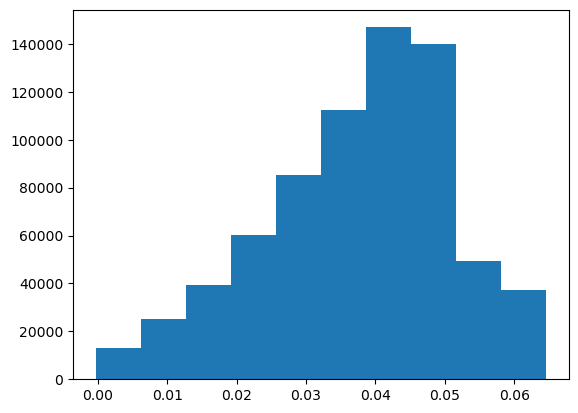

In [97]:
plt.hist(galaxies['z'])

In [98]:
# l, b = radec_to_galactic(galaxies['ra'], galaxies['dec'])
# galaxies['l'] = l
# galaxies['b'] = b

# galaxies.head()

In [99]:
from astropy.coordinates import SkyCoord

# LMC / SMC Galactic coordinates
l_gal = np.array([0, 280.5, 302.8])
b_gal = np.array([0, -32.9, -44.3])
sc_gal = SkyCoord(l=l_gal, b=b_gal, unit='deg', frame='galactic').icrs
size_gal = np.array([40, 7, 5])

In [100]:
# galaxies = galaxies[np.abs(galaxies['b']) > 15]
galaxies["ra"].size  # 3 M galaxies with z < 0.1

709426

In [101]:
def angular_distance(ra1, dec1, ra2, dec2):
    """Angular distance (See [Степанов, "Сферическая тригонометрия" (1948)])

    :param ra1: [deg]
    :param dec1: [deg]
    :param ra2: [deg]
    :param dec2: [deg]
    :return: [deg]
    """
    ra1, dec1, ra2, dec2 = map(np.radians, [ra1, dec1, ra2, dec2])  # to radians
    return np.degrees(np.arccos(
        np.sin(dec1)*np.sin(dec2) +
        np.cos(dec1)*np.cos(dec2)*np.cos(ra1 - ra2)
    ))

In [102]:
# for i in range(len(l_gal)):
#     galaxies = galaxies[angular_distance(sc_gal.ra.deg[i], sc_gal.dec.deg[i], galaxies.ra, galaxies.dec) > size_gal[i]]

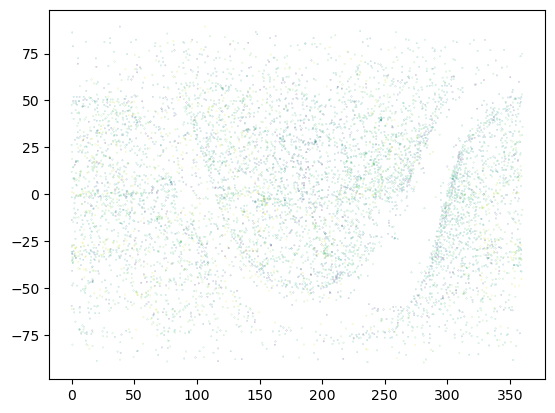

In [103]:
plt.scatter(galaxies.ra[::100], galaxies.dec[::100], c=galaxies.z[::100], s=0.01)

## Random galaxy distribution

### Mask

In [104]:
nside = 128
npix = hp.nside2npix(nside)

mask = np.zeros(npix)

good = (galaxies.z > 0.01) * (galaxies.z < 0.05)
galaxies = galaxies[good]
ra, dec = np.array(galaxies.ra), np.array(galaxies.dec)
z = np.array(galaxies.z)

theta_data = np.radians(90 - dec)
phi_data   = np.radians(ra)

# 1. build mask from catalog
mask = np.zeros(npix)
pix = hp.ang2pix(nside, theta_data, phi_data)
mask[pix] = 1

# 2. smooth / fill
mask = hp.smoothing(mask, sigma=np.radians(4.0))
mask = (mask > 0.6).astype(float)

# 3. apply Galactic cut (pixel space!)
theta_pix, phi_pix = hp.pix2ang(nside, np.arange(npix))
b_pix = 90.0 - np.degrees(theta_pix)

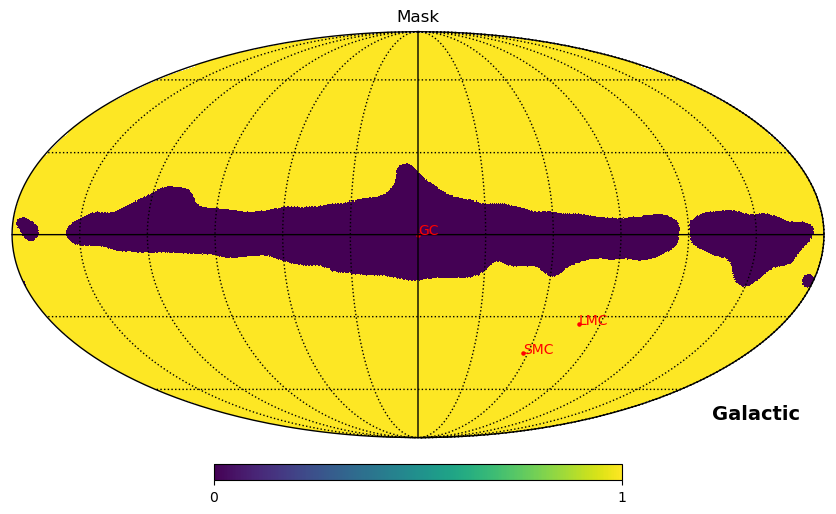

In [105]:
from astropy.coordinates import SkyCoord
import astropy.units as u

hp.mollview(mask, title="Mask", coord=['C', 'G'], min=0, max=1)

objects = SkyCoord(l=l_gal, b=b_gal, unit='deg', frame='galactic')
    
# convert to healpy angles
theta_gal = np.radians(90 - b_gal)
phi_gal   = np.radians(l_gal)

# overplot
hp.projscatter(theta_gal, phi_gal, marker='o', color='red', s=5)

# optional labels
hp.projtext(theta_gal[0], phi_gal[0], "GC", color='red')
hp.projtext(theta_gal[1], phi_gal[1], "LMC", color='red')
hp.projtext(theta_gal[2], phi_gal[2], "SMC", color='red')

hp.graticule()
plt.show()

### Distribution in redshifts

In [106]:
from scipy.ndimage import gaussian_filter1d

hist, edges = np.histogram(np.log10(z), bins=50, density=True)
z_centers = 0.5 * (edges[1:] + edges[:-1])

# smooth
nz = gaussian_filter1d(hist, sigma=1.0)

# normalize
nz /= np.trapz(nz, z_centers)

In [107]:
# GENERATE A RANDOM SOURCE FIELD 
N_rand = 20 * galaxies.z.size
print(galaxies.z.size)

cdf = np.cumsum(nz)
cdf /= cdf[-1]

def sample_z(N):
    u = np.random.rand(N)
    return np.interp(u, cdf, z_centers)

z_rand = 10**sample_z(N_rand)

578044


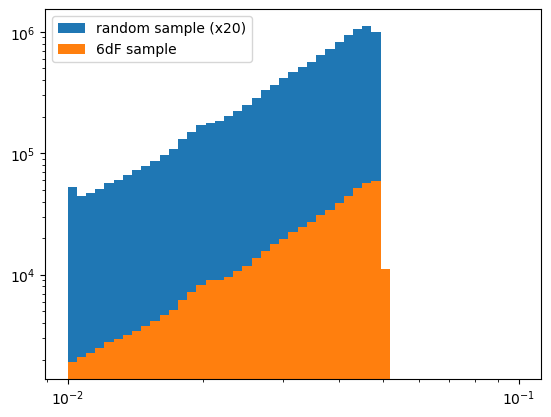

In [108]:
z_bins = np.logspace(-2, -1, 50)
plt.hist(z_rand, bins=z_bins, label='random sample (x20)')
plt.hist(galaxies.z, bins=z_bins, label='6dF sample')
plt.legend()
plt.yscale('log')
plt.xscale('log')

### Combine with the mask

In [109]:
# distributing random sources in the sky

prob = mask.astype(float)
prob /= prob.sum()   # normalize

# draw pixel indices
npix = len(mask)
pix_rand = np.random.choice(np.arange(npix), size=N_rand, p=prob)

# convert to angles
theta_pix, phi_pix = hp.pix2ang(nside, pix_rand)

# pixel size
res = hp.nside2resol(nside)

# add sub-pixel jitter
theta_rand = theta_pix 
phi_rand   = phi_pix 

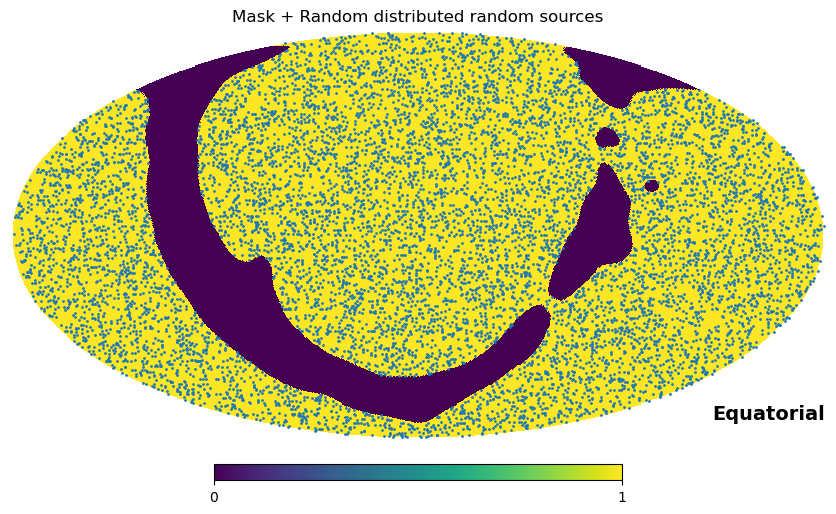

In [110]:
# sanity check of the randomly distributed sources
hp.mollview(mask, title="Mask + Random distributed random sources", rot=(180, 0, 0), coord='C')
hp.projscatter(theta_rand[:10000], phi_rand[:10000], s=1)
plt.show()

## Overdensity maps

In [111]:
# OVERDENSITY VALUE

nside = 128
npix = hp.nside2npix(nside)

# data
pix_d = hp.ang2pix(nside, theta_data, phi_data)
counts_d = np.bincount(pix_d, minlength=npix)

# randoms
pix_r = hp.ang2pix(nside, theta_rand, phi_rand)
counts_r = np.bincount(pix_r, minlength=npix)

In [112]:
counts_d = counts_d * mask

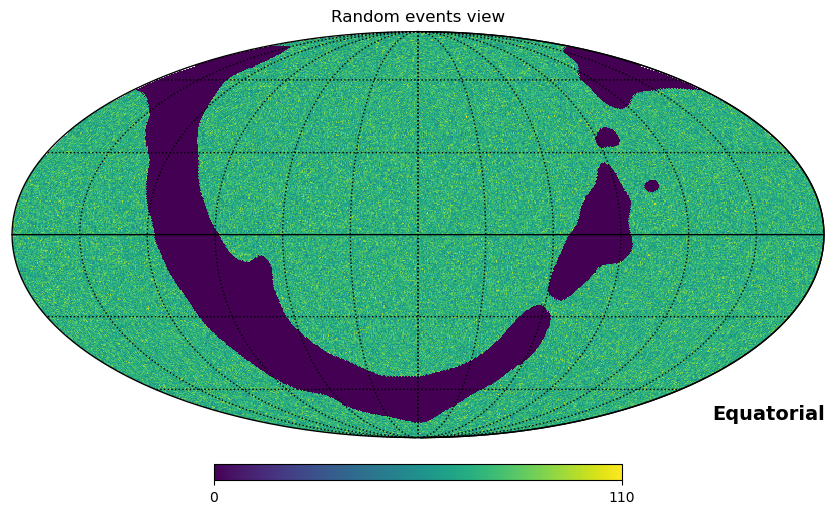

In [113]:
hp.mollview(counts_r, title="Random events view", rot=(180, 0, 0), coord='C')
hp.graticule()

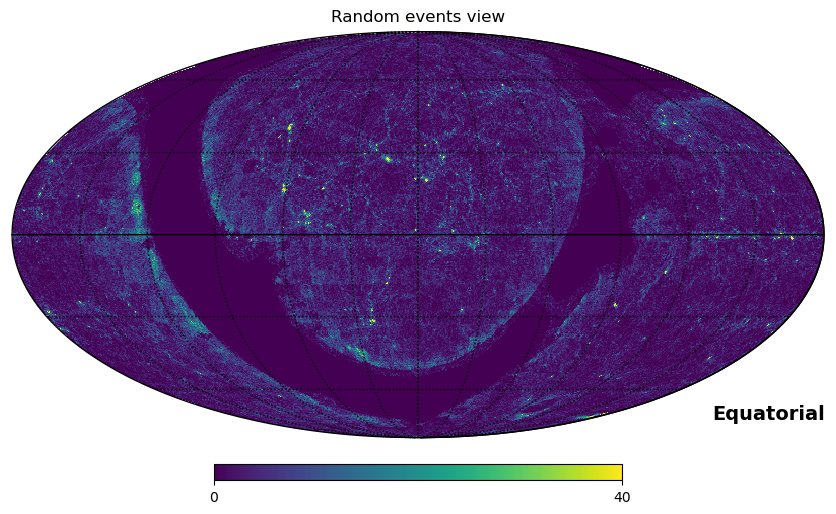

In [114]:
hp.mollview(counts_d, title="Random events view", rot=(180, 0, 0), coord='C', min=0, max=40)
hp.graticule()

In [115]:
# normalization coefficient (data / sampling)
alpha = len(theta_data) / len(theta_rand)

# OVERDENSITY FUNCTION
delta = np.zeros(npix, dtype=float)

valid = counts_r > 0
delta[valid] = counts_d[valid] / (alpha * counts_r[valid]) - 1

delta_s = hp.smoothing(delta, sigma=np.radians(1.0)) * mask

In [116]:
print(np.nanmean(delta[valid]))   # should be ~0
print(np.nanstd(delta[valid]))    # reasonable scatter

-0.01789632392284419
1.0758833435486483


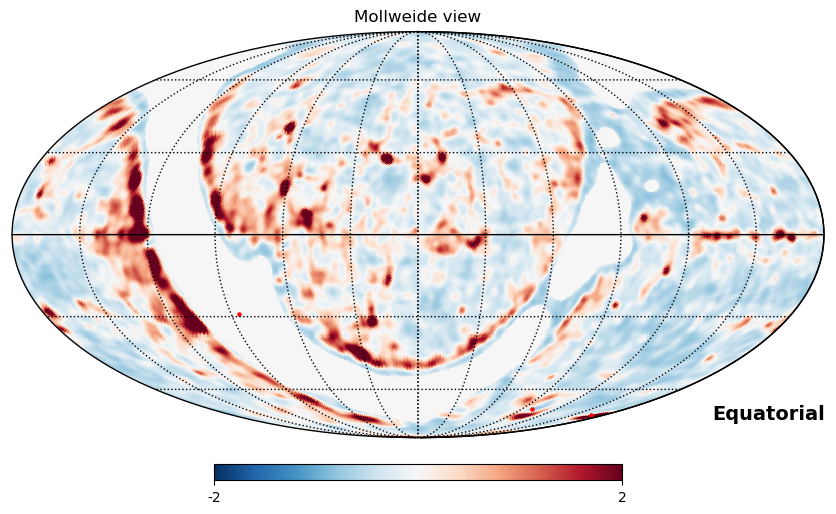

In [117]:
hp.mollview(delta_s, cmap='RdBu_r', min=-2, max=2, rot=(180, 0, 0), coord='C')
hp.projscatter(theta_gal, phi_gal, coord=['G', 'C'], marker='o', color='red', s=5)
hp.graticule()

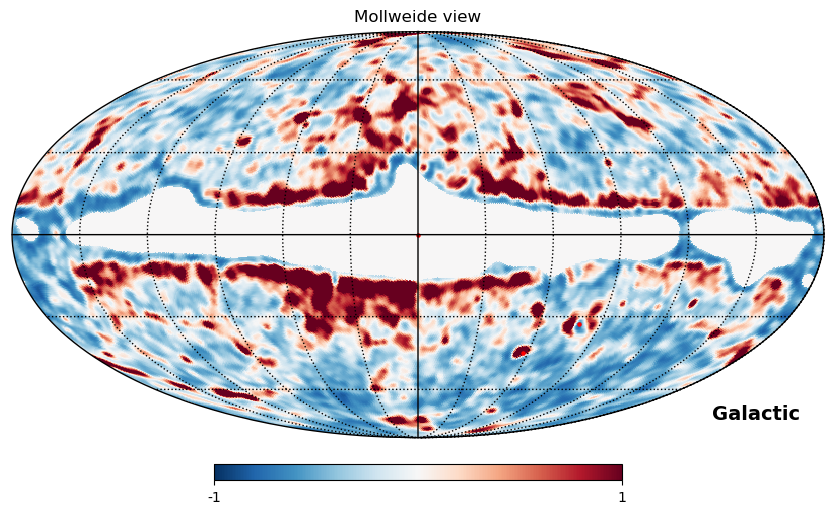

In [118]:
hp.mollview(delta_s, coord=['C', 'G'], cmap='RdBu_r', min=-1, max=1)
hp.projscatter(theta_gal, phi_gal, coord='G', marker='o', color='red', s=5)
hp.graticule()